# Week 2 - Maryi Tatiana Palacios Giraldo

# GridWorld

In [21]:
import numpy as np

class GridWorld:
    def __init__(self, size=4, stochastic=False):
        self.size = size
        self.n_states = size * size
        self.n_actions = 4  
        self.stochastic = stochastic

        self.actions = {
            0: (-1, 0),  
            1: (1, 0),   
            2: (0, -1),  
            3: (0, 1)    
        }
        
        self.terminal_states = [0, self.n_states - 1]

        
        self.P = self._build_transition_model()

    def _to_state(self, row, col):
        return row * self.size + col

    def _to_pos(self, state):
        return divmod(state, self.size)

    def _build_transition_model(self):
        """
        Builds P(s', r | s, a)
        Returns:
            dict: P[state][action] = list of (prob, next_state, reward, done)
        """
        P = {s: {a: [] for a in range(self.n_actions)} for s in range(self.n_states)}

        for s in range(self.n_states):
            row, col = self._to_pos(s)

            for a in range(self.n_actions):

                # terminal states
                if s in self.terminal_states:
                    P[s][a] = [(1.0, s, 0, True)]
                    continue

                transitions = []

                
                if self.stochastic:
                    probs = [
                        (a, 0.8),
                        ((a + 1) % 4, 0.1),
                        ((a - 1) % 4, 0.1)
                    ]
                else:
                    probs = [(a, 1.0)]

                for action, prob in probs:
                    dr, dc = self.actions[action]

                    new_r = min(max(row + dr, 0), self.size - 1)
                    new_c = min(max(col + dc, 0), self.size - 1)

                    next_state = self._to_state(new_r, new_c)

                    reward = -1
                    done = next_state in self.terminal_states

                    transitions.append((prob, next_state, reward, done))

                P[s][a] = transitions

        return P

# Test

In [18]:
env = GridWorld(size=4, stochastic=True)

print("Number of states:", env.n_states)
print("Number of actions:", env.n_actions)

print("\nExample transition (state 5, action RIGHT=3):")
print(env.P[5][3])

Number of states: 16
Number of actions: 4

Example transition (state 5, action RIGHT=3):
[(0.8, 6, -1, False), (0.1, 1, -1, False), (0.1, 4, -1, False)]


# Policy Evaluation

In [19]:
def policy_evaluation(env, policy, gamma=0.99, theta=1e-6):
    V = np.zeros(env.n_states)

    while True:
        delta = 0

        for s in range(env.n_states):
            v = 0

            for a, action_prob in enumerate(policy[s]):
                for prob, next_state, reward, _ in env.P[s][a]:
                    v += action_prob * prob * (reward + gamma * V[next_state])

            delta = max(delta, abs(v - V[s]))
            V[s] = v

        if delta < theta:
            break

    return V

In [20]:
policy = np.ones((env.n_states, env.n_actions)) / env.n_actions

V = policy_evaluation(env, policy)

print(V.reshape(4, 4))

[[  0.         -11.94520053 -16.96108384 -18.60541793]
 [-11.94520053 -15.31675016 -16.97752783 -16.96108458]
 [-16.96108384 -16.97752783 -15.31675079 -11.94520152]
 [-18.60541793 -16.96108458 -11.94520152   0.        ]]


# Visualization

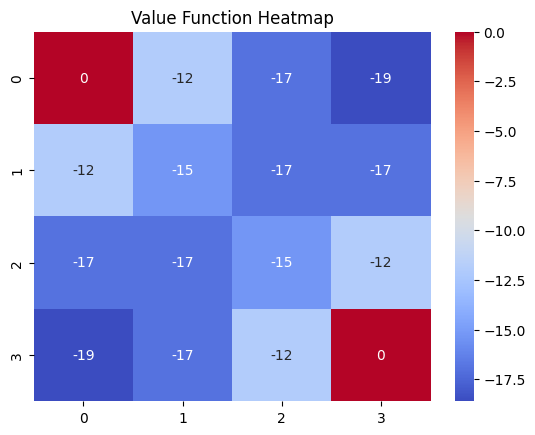

In [22]:
import matplotlib.pyplot as plt
import seaborn as sns

def plot_value_function(V, size):
    grid = V.reshape(size, size)
    sns.heatmap(grid, annot=True, cmap="coolwarm")
    plt.title("Value Function Heatmap")
    plt.show()

plot_value_function(V, 4)

In [23]:
def policy_iteration(env, gamma=0.99):
    # inicial policy random
    policy = np.ones((env.n_states, env.n_actions)) / env.n_actions

    while True:
        # 1. evaluar policy
        V = policy_evaluation(env, policy, gamma)

        policy_stable = True

        # 2. mejorar policy
        for s in range(env.n_states):
            old_action = np.argmax(policy[s])

            action_values = np.zeros(env.n_actions)

            for a in range(env.n_actions):
                for prob, next_state, reward, _ in env.P[s][a]:
                    action_values[a] += prob * (reward + gamma * V[next_state])

            best_action = np.argmax(action_values)

            # actualizar policy
            policy[s] = np.eye(env.n_actions)[best_action]

            if old_action != best_action:
                policy_stable = False

        if policy_stable:
            break

    return policy, V

# POLICY ITERATION

In [44]:
def policy_iteration(env, gamma=0.99):
    
    policy = np.ones((env.n_states, env.n_actions)) / env.n_actions

    while True:
       
        V = policy_evaluation(env, policy, gamma)

        policy_stable = True

        
        for s in range(env.n_states):
            old_action = np.argmax(policy[s])

            action_values = np.zeros(env.n_actions)

            for a in range(env.n_actions):
                for prob, next_state, reward, _ in env.P[s][a]:
                    action_values[a] += prob * (reward + gamma * V[next_state])

            best_action = np.argmax(action_values)

           
            policy[s] = np.eye(env.n_actions)[best_action]

            if old_action != best_action:
                policy_stable = False

        if policy_stable:
            break

    return policy, V

In [25]:
policy_pi, V_pi = policy_iteration(env)

print(V_pi.reshape(4,4))

[[ 0.         -1.61033226 -3.08826736 -4.16386924]
 [-1.61033226 -3.07670555 -4.04708311 -3.08826748]
 [-3.08826736 -4.04708311 -3.07670565 -1.61033234]
 [-4.16386924 -3.08826748 -1.61033234  0.        ]]


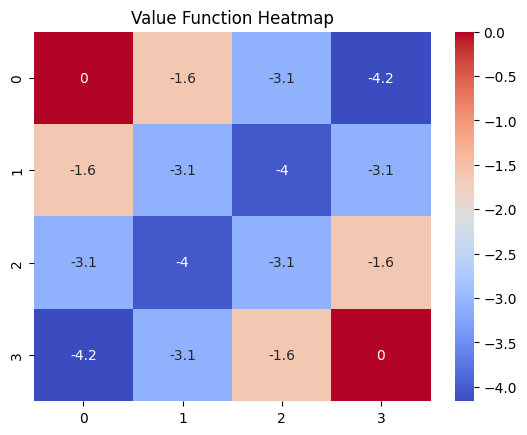

In [26]:
plot_value_function(V_pi, 4)

The value function obtained from Policy Iteration shows a clear gradient toward the terminal states, with less negative values compared to the initial random policy. This indicates that the algorithm successfully found an optimal policy minimizing the expected cumulative penalty.

In [27]:
def value_iteration(env, gamma=0.99, theta=1e-6):
    V = np.zeros(env.n_states)

    while True:
        delta = 0

        for s in range(env.n_states):
            action_values = np.zeros(env.n_actions)

            for a in range(env.n_actions):
                for prob, next_state, reward, _ in env.P[s][a]:
                    action_values[a] += prob * (reward + gamma * V[next_state])

            max_value = np.max(action_values)
            delta = max(delta, abs(max_value - V[s]))
            V[s] = max_value

        if delta < theta:
            break

    # extraer policy
    policy = np.zeros((env.n_states, env.n_actions))

    for s in range(env.n_states):
        action_values = np.zeros(env.n_actions)

        for a in range(env.n_actions):
            for prob, next_state, reward, _ in env.P[s][a]:
                action_values[a] += prob * (reward + gamma * V[next_state])

        best_action = np.argmax(action_values)
        policy[s] = np.eye(env.n_actions)[best_action]

    return policy, V

In [29]:
policy_vi, V_vi = value_iteration(env)

print(V_vi.reshape(4,4))

[[ 0.         -1.61033226 -3.08826736 -4.16386923]
 [-1.61033226 -3.07670555 -4.04708311 -3.08826748]
 [-3.08826736 -4.04708311 -3.07670565 -1.61033234]
 [-4.16386923 -3.08826748 -1.61033234  0.        ]]


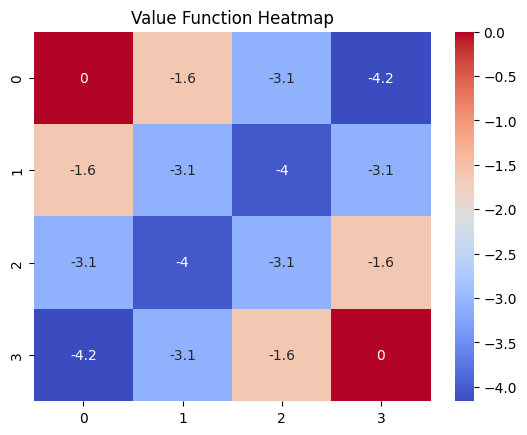

In [30]:
plot_value_function(V_vi, 4)

Both Policy Iteration and Value Iteration converge to the same optimal value function, as expected from Dynamic Programming theory, since both methods solve the Bellman optimality equation.

In [31]:
def plot_policy(policy, size):
    arrows = ['↑', '↓', '←', '→']
    grid = np.argmax(policy, axis=1).reshape(size, size)

    for row in grid:
        print(" ".join(arrows[a] for a in row))

In [32]:
print("Policy Iteration Policy:")
plot_policy(policy_pi, 4)

print("\nValue Iteration Policy:")
plot_policy(policy_vi, 4)

Policy Iteration Policy:
↑ ← ← ←
↑ ↑ ← ↓
↑ ↑ ↓ ↓
↑ → → ↑

Value Iteration Policy:
↑ ← ← ←
↑ ↑ ← ↓
↑ ↑ ↓ ↓
↑ → → ↑


Both Policy Iteration and Value Iteration converge to the same optimal policy, confirming theoretical expectations. The arrows consistently point toward the terminal states, indicating that the agent follows the shortest path to minimize cumulative negative rewards.

In [33]:
import time

def measure_time(func, env):
    start = time.time()
    policy, V = func(env)
    end = time.time()
    return end - start

In [34]:
env_det = GridWorld(size=4, stochastic=False)
env_sto = GridWorld(size=4, stochastic=True)

print("Deterministic Environment:")
print("Policy Iteration:", measure_time(policy_iteration, env_det))
print("Value Iteration:", measure_time(value_iteration, env_det))

print("\nStochastic Environment:")
print("Policy Iteration:", measure_time(policy_iteration, env_sto))
print("Value Iteration:", measure_time(value_iteration, env_sto))

Deterministic Environment:
Policy Iteration: 0.016022443771362305
Value Iteration: 0.002263784408569336

Stochastic Environment:
Policy Iteration: 0.023896217346191406
Value Iteration: 0.0046520233154296875


The results show that Value Iteration converges significantly faster than Policy Iteration in both deterministic and stochastic environments. This is expected because Value Iteration directly updates the value function using the Bellman optimality equation, avoiding the costly full policy evaluation step required in Policy Iteration.

Additionally, the stochastic environment leads to slower convergence for both algorithms. This is due to the uncertainty in transitions, which requires the algorithms to account for multiple possible outcomes at each step. As a result, value updates become more complex and convergence takes longer.

Despite differences in convergence speed, both algorithms produce identical optimal policies and value functions, confirming theoretical expectations from Dynamic Programming (Sutton & Barto, Chapter 4).

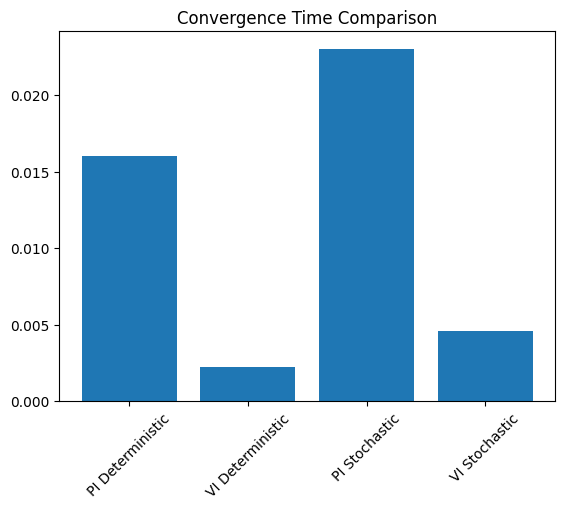

In [35]:
import matplotlib.pyplot as plt

labels = ['PI Deterministic', 'VI Deterministic', 'PI Stochastic', 'VI Stochastic']
times = [0.016, 0.0022, 0.023, 0.0046]

plt.bar(labels, times)
plt.title("Convergence Time Comparison")
plt.xticks(rotation=45)
plt.show()

In [38]:
!pip install gymnasium

   ---------------------------------------- 0.0/965.4 kB ? eta -:--:--
   ---------- ----------------------------- 262.1/965.4 kB ? eta -:--:--
   -------------------------------- ------- 786.4/965.4 kB 2.2 MB/s eta 0:00:01
   ---------------------------------------- 965.4/965.4 kB 2.1 MB/s eta 0:00:00

   -------------------- ------------------- 1/2 [gymnasium]
   -------------------- ------------------- 1/2 [gymnasium]
   -------------------- ------------------- 1/2 [gymnasium]
   -------------------- ------------------- 1/2 [gymnasium]
   -------------------- ------------------- 1/2 [gymnasium]
   -------------------- ------------------- 1/2 [gymnasium]
   -------------------- ------------------- 1/2 [gymnasium]
   -------------------- ------------------- 1/2 [gymnasium]
   -------------------- ------------------- 1/2 [gymnasium]
   -------------------- ------------------- 1/2 [gymnasium]
   -------------------- ------------------- 1/2 [gymnasium]
   -------------------- -----------


[notice] A new release of pip is available: 25.1.1 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


# FrozenLake

In [39]:
import gymnasium as gym

env_fl = gym.make("FrozenLake-v1", is_slippery=True)
env_fl = env_fl.unwrapped

print(env_fl.P[0][1])

[(0.3333333333333333, 0, 0.0, False), (0.3333333333333333, 4, 0.0, False), (0.3333333333333333, 1, 0.0, False)]


In [40]:
class FrozenLakeWrapper:
    def __init__(self, env):
        self.P = env.P
        self.n_states = env.observation_space.n
        self.n_actions = env.action_space.n

[[0.54201404 0.49878743 0.47067727 0.45683193]
 [0.5584404  0.         0.35834012 0.        ]
 [0.59179013 0.64307363 0.61520214 0.        ]
 [0.         0.74171617 0.86283528 0.        ]]


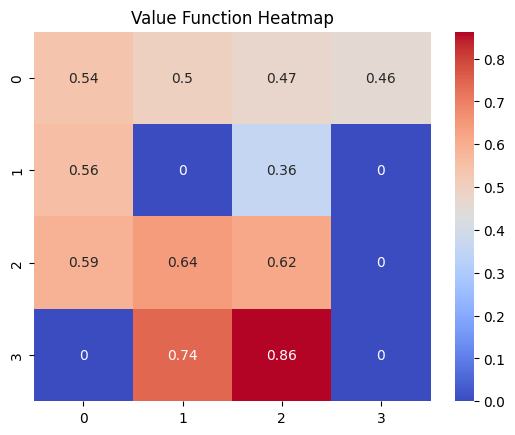

In [42]:
env_frozen = FrozenLakeWrapper(env_fl)

policy_fl, V_fl = value_iteration(env_frozen)

print(V_fl.reshape(4,4))
plot_value_function(V_fl, 4)

In [43]:
plot_policy(policy_fl, 4)

↑ → → →
↑ ↑ ↑ ↑
→ ↓ ↑ ↑
↑ ← ↓ ↑


The optimal policy in FrozenLake appears less structured and less direct compared to GridWorld. This is due to the high level of stochasticity in the environment, where actions do not always lead to the intended outcome.

As a result, the agent adopts a more cautious strategy, avoiding risky transitions and favoring actions that increase the probability of eventually reaching the goal. This demonstrates how uncertainty in transition dynamics significantly affects optimal decision-making in Markov Decision Processes.

# Versión synchronous

In [46]:
def policy_evaluation_sync(env, policy, gamma=0.99, theta=1e-6):
    V = np.zeros(env.n_states)

    while True:
        delta = 0
        new_V = np.zeros(env.n_states)

        for s in range(env.n_states):
            v = 0
            for a, action_prob in enumerate(policy[s]):
                for prob, next_state, reward, _ in env.P[s][a]:
                    v += action_prob * prob * (reward + gamma * V[next_state])

            new_V[s] = v
            delta = max(delta, abs(v - V[s]))

        V = new_V

        if delta < theta:
            break

    return V